## AlphaGenome genomAD Variant Analysis

This notebook analyzes AlphaGenome variant scoring results and generates visualizations and summary tables.

## Setup
1. Set the `INPUT_PATH` variable to point to either:
   - A single CSV file (e.g., `AlphaGenome_batch_variant_score_splicing.csv`)
   - A directory containing multiple `alphagenome_scores_*.csv` files
2. Set the `OUTPUT_DIR` variable for saving results
3. Run all cells in order

## 1. Configuration

In [4]:
# ============================================
# CONFIGURATION - MODIFY THESE PATHS
# ============================================

# Input: Can be a single CSV file OR a directory with multiple alphagenome_scores_*.csv files
INPUT_PATH = "../01_alphagenome_analysis/alphagenome_intron6_genomAD/csv/" 

OUTPUT_DIR = "./plots_alphagenome_genomAD/"  # Directory for output files

# Pathogenicity thresholds (can be customized)
THRESHOLD_HIGH = 0.999      # Top 0.1%
THRESHOLD_MODERATE = 0.99   # Top 1%
THRESHOLD_LOW = 0.95        # Top 5%

## 2. Import Libraries

In [5]:
import glob
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input path: {INPUT_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Input path: ../01_alphagenome_analysis/alphagenome_intron6_genomAD/csv/
Output directory: ./plots_alphagenome_genomAD/


## 3. Data Loading Function

In [6]:
def load_alphagenome_data(input_path: str) -> pd.DataFrame:
    """
    Load AlphaGenome data from either a single CSV file or a directory of CSV files.
    
    Parameters
    ----------
    input_path : str
        Path to a single CSV file or directory containing alphagenome_scores_*.csv files
        
    Returns
    -------
    pd.DataFrame
        Combined dataframe with all variant scores
    """
    input_path = Path(input_path)
    
    if input_path.is_file():
        # Single file input
        print(f"Loading single file: {input_path.name}")
        combined_df = pd.read_csv(input_path)
    elif input_path.is_dir():
        # Directory with multiple files
        file_pattern = str(input_path / 'alphagenome_scores_*.csv')
        files = glob.glob(file_pattern)
        
        if not files:
            # Try alternative pattern
            file_pattern = str(input_path / '*.csv')
            files = glob.glob(file_pattern)
        
        if not files:
            raise FileNotFoundError(f"No CSV files found in {input_path}")
        
        print(f"Found {len(files)} CSV files:")
        for f in sorted(files):
            print(f"  - {os.path.basename(f)}")
        
        dfs = [pd.read_csv(f) for f in files]
        combined_df = pd.concat(dfs, ignore_index=True)
    else:
        raise FileNotFoundError(f"Input path not found: {input_path}")
    
    # Clean up - remove unnamed index column if present
    if 'Unnamed: 0' in combined_df.columns:
        combined_df = combined_df.drop(columns=['Unnamed: 0'])
    
    # Data quality checks
    print(f"\n--- Data Quality Check ---")
    print(f"Total rows: {combined_df.shape[0]}")
    print(f"Total columns: {combined_df.shape[1]}")
    
    # Check for duplicate columns
    dup_cols = combined_df.columns[combined_df.columns.duplicated()].tolist()
    if dup_cols:
        print(f"WARNING: Duplicate columns found: {dup_cols}")
        combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    else:
        print("✓ No duplicate columns")
    
    return combined_df

## 4. Pathogenicity Classification Function

In [7]:
def classify_pathogenicity(quantile: float, 
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> str:
    """
    Classify variant pathogenicity based on quantile score.
    
    Parameters
    ----------
    quantile : float
        AlphaGenome quantile score (0-1)
    threshold_high : float
        Threshold for High Impact classification
    threshold_moderate : float
        Threshold for Moderate Impact classification
    threshold_low : float
        Threshold for Low Impact classification
        
    Returns
    -------
    str
        Impact classification
    """
    if quantile >= threshold_high:
        return 'High Impact'
    elif quantile >= threshold_moderate:
        return 'Moderate Impact'
    elif quantile >= threshold_low:
        return 'Low Impact'
    else:
        return 'No Impact'

## 5. Variant Summary Function

In [8]:
def create_variant_summary(combined_df: pd.DataFrame,
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> pd.DataFrame:
    """
    Create summary statistics for each variant.
    
    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
        
    Returns
    -------
    pd.DataFrame
        Summary dataframe with one row per variant
    """
    variant_summary = []
    
    for variant in combined_df['variant_id'].unique():
        var_data = combined_df[combined_df['variant_id'] == variant]
        
        # Extract position and change from variant_id
        parts = variant.split(':')
        position = int(parts[1])
        change = parts[2]
        
        # Get scores by output type
        splice_junction_data = var_data[var_data['output_type'] == 'SPLICE_JUNCTIONS']
        splice_site_data = var_data[var_data['output_type'] == 'SPLICE_SITE_USAGE']
        
        summary = {
            'variant_id': variant,
            'position': position,
            'change': change,
            'n_predictions': len(var_data),
            # Splice junction scores
            'splice_junction_max_raw': splice_junction_data['raw_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_max_quantile': splice_junction_data['quantile_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_raw': splice_junction_data['raw_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_quantile': splice_junction_data['quantile_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            # Splice site usage scores
            'splice_site_max_raw': splice_site_data['raw_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_max_quantile': splice_site_data['quantile_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_raw': splice_site_data['raw_score'].mean() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_quantile': splice_site_data['quantile_score'].mean() if len(splice_site_data) > 0 else np.nan,
        }
        
        # Overall max scores
        summary['overall_max_raw'] = var_data['raw_score'].max()
        summary['overall_max_quantile'] = var_data['quantile_score'].max()
        summary['overall_mean_quantile'] = var_data['quantile_score'].mean()
        
        variant_summary.append(summary)
    
    summary_df = pd.DataFrame(variant_summary)
    summary_df = summary_df.sort_values('overall_max_quantile', ascending=False)
    
    # Add classifications (harmonized with alphagenome_analysis_notebook_cohort.ipynb)
    summary_df['short_variant'] = summary_df['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )
    # Classification is based on the SPLICE_SITE_USAGE quantile score only.
    # If a variant has no SPLICE_SITE_USAGE prediction, it is labelled as 'Not Evaluated'.
    summary_df['impact_class'] = summary_df['splice_site_max_quantile'].apply(
        lambda x: classify_pathogenicity(x, threshold_high, threshold_moderate, threshold_low)
        if pd.notna(x) else 'Not Evaluated'
    )
    
    return summary_df

## 6. Visualization Functions

### 6.1 Scores Heatmap

In [16]:
def plot_scores_heatmap(combined_df: pd.DataFrame, summary_df: pd.DataFrame, output_dir: str = None):
    """
    Create heatmap of scores by variant and output type.
    
    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving plots
    """
    def _heatmap_row_label(sv: str, max_total: int = 36, change_edge: int = 5) -> str:
        """Shorten long pos:change labels so row text fits the heatmap."""
        if len(sv) <= max_total:
            return sv
        if ':' in sv:
            pos, ch = sv.split(':', 1)
            if len(ch) > 2 * change_edge + 3:
                ch = ch[:change_edge] + '...' + ch[-change_edge:]
            return f"{pos}:{ch}"
        return sv[: max_total - 3] + '...'
    # Get max quantile score for each variant and output type.
    heatmap_data = (
        combined_df.groupby(['variant_id', 'output_type'])['quantile_score']
        .max()
        .reset_index()
    )
    
    # Pivot by variant_id first (stable key) to avoid label-mismatch drops.
    heatmap_pivot = heatmap_data.pivot(index='variant_id', columns='output_type', values='quantile_score')

    # Sort by overall impact using variant_id ordering from summary_df.
    order_ids = summary_df.sort_values('overall_max_quantile', ascending=False)['variant_id'].tolist()
    heatmap_pivot = heatmap_pivot.reindex(order_ids)

    label_map = dict(zip(summary_df['variant_id'], summary_df['short_variant']))
    heatmap_pivot.index = [_heatmap_row_label(label_map.get(v, v)) for v in heatmap_pivot.index]
    
    n_rows = len(heatmap_pivot.index)
    fig_h = max(5.0, min(14.0, 0.45 * n_rows + 3.0))
    fig, ax = plt.subplots(figsize=(6.5, fig_h))
    
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn_r',
        vmin=0.9,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Quantile Score'},
        ax=ax
    )
    
    ax.set_title('AlphaGenome scores by variant and prediction type', fontsize=10)
    ax.set_xlabel('Prediction Type', fontsize=8)
    ax.set_ylabel('', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, ha='right')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.svg'), bbox_inches='tight')
        print("Saved: variant_scores_heatmap.png/svg")
    
    plt.show()

### 6.2 Genomic Position Plot

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import os

def plot_genomic_positions(summary_df: pd.DataFrame, output_dir: str = None):
    """
    Create lollipop plot showing variant positions and scores.
    Variants at the same position are aligned together with small offsets.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe with columns: position, change, splice_site_max_quantile, impact_class
    output_dir : str, optional
        Output directory for saving plots
    """
    impact_colors = {
        'High Impact': '#D32F2F',
        'Moderate Impact': '#FF9800',
        'Low Impact': '#4CAF50',
        'No Impact': '#FFC107',
        'Not Evaluated': '#9E9E9E',
    }
    
    # Sort by position and change
    plot_df = summary_df.sort_values(['position', 'change']).reset_index(drop=True)
    # Y-axis: splice-site quantile (same basis as classify_pathogenicity); fallback if missing.
    plot_df['_plot_quantile'] = plot_df['splice_site_max_quantile'].fillna(
        plot_df['overall_max_quantile']
    )
    
    # For variants at same position, add small horizontal offset
    plot_df['pos_count'] = plot_df.groupby('position').cumcount()
    plot_df['pos_total'] = plot_df.groupby('position')['position'].transform('count')
    
    # Small offset (1.5 bp) for variants at same position, centered
    plot_df['x_plot'] = plot_df['position'] + (plot_df['pos_count'] - (plot_df['pos_total']-1)/2) * 1.5
    
    # Vertical staggering for labels to prevent overlap
    plot_df['label_y_offset'] = plot_df['pos_count'] * 0.004  # Stagger labels vertically
    
    # Create figure with black border
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Plot lollipop stems and points
    for _, row in plot_df.iterrows():
        color = impact_colors.get(row['impact_class'], '#9E9E9E')
        
        # Stem (from baseline to point)
        ax.plot([row['x_plot'], row['x_plot']], [0.9, row['_plot_quantile']], 
                color=color, linewidth=1.5, zorder=1)
        
        # Point
        ax.scatter(row['x_plot'], row['_plot_quantile'], 
                   color=color, s=80, zorder=2, edgecolors='white', linewidths=0.5)
        
        # Label position (with vertical staggering and base offset)
        label_y = row['_plot_quantile'] + 0.008 + row['label_y_offset']
        
        # Connector line from point to label
        ax.plot([row['x_plot'], row['x_plot']], 
                [row['_plot_quantile'], label_y - 0.002],
                color='gray', linewidth=0.5, linestyle=':', alpha=0.5, zorder=1)
        
        # Label (truncate very long allele strings for readability)
        _ch = row['change']
        label_text = _ch[:3] + '...' + _ch[-3:] if len(_ch) > 10 else _ch
        ax.annotate(label_text, 
                    xy=(row['x_plot'], label_y),
                    ha='center', va='bottom',
                    fontsize=8, color=color, fontweight='bold')
    
    # Add threshold lines
    ax.axhline(y=0.999, color='#D32F2F', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
    ax.axhline(y=0.99, color='#FF9800', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
    
    # Set axis properties
    ax.set_xlabel('Genomic Position (COL4A5 intron 6)', fontsize=11)
    ax.set_ylabel('Maximum Quantile Score', fontsize=11)
    ax.set_title('Variant Impact Scores Along Genomic Region\nGenomic positions with nucleotide changes labeled', 
                 fontsize=13, fontweight='bold', pad=15)
    
    # Y-axis from 0.9 to 1.02 (more room for labels)
    ax.set_ylim(0.9, 1.02)
    ax.set_yticks([0.90, 0.95, 0.99, 0.999])
    
    # X-axis: use actual genomic positions
    unique_positions = sorted(plot_df['position'].unique())
    ax.set_xticks(unique_positions)
    ax.set_xticklabels([f"{p:,}" for p in unique_positions], rotation=90, ha='right', fontsize=8)
    
    # Set x limits with padding
    x_min = plot_df['x_plot'].min() - 5
    x_max = plot_df['x_plot'].max() + 5
    ax.set_xlim(x_min, x_max)
    
    # BLACK BORDER - set all spines to black and visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    
    # NO GRID - white background
    ax.grid(False)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    
    # Add legend OUTSIDE the plot area
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#D32F2F', markersize=10, label='High Impact'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800', markersize=10, label='Moderate Impact'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50', markersize=10, label='Low Impact'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFC107', markersize=10, label='No Impact'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
              title='Impact Class', fontsize=9, frameon=True, fancybox=False, edgecolor='black')
    
    plt.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, 'variant_genomic_positions.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'variant_genomic_positions.svg'), bbox_inches='tight')
        print("Saved: variant_genomic_positions.png/svg")
    
    plt.close()
    return fig

## 7. Summary Table Function

In [18]:
def save_summary_table(summary_df: pd.DataFrame, output_dir: str = None) -> pd.DataFrame:
    """
    Save the variant summary table to CSV.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving the table
        
    Returns
    -------
    pd.DataFrame
        Formatted summary table
    """
    final_summary = summary_df[['variant_id', 'position', 'change', 'impact_class',
                                'overall_max_quantile', 'overall_max_raw', 'overall_mean_quantile',
                                'splice_junction_max_quantile', 'splice_site_max_quantile',
                                'n_predictions']].copy()
    
    final_summary = final_summary.sort_values('overall_max_quantile', ascending=False)
    final_summary.columns = ['Variant ID', 'Position', 'Change', 'Impact Classification',
                             'Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                             'Splice Junction Max', 'Splice Site Max', 'N Predictions']
    
    # Round numeric columns
    numeric_cols = ['Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                    'Splice Junction Max', 'Splice Site Max']
    for col in numeric_cols:
        final_summary[col] = final_summary[col].round(6)
    
    if output_dir:
        output_path = os.path.join(output_dir, 'variant_pathogenicity_summary.csv')
        final_summary.to_csv(output_path, index=False)
        print(f"Saved: variant_pathogenicity_summary.csv")
    
    return final_summary

## 8. Classification Summary Function

In [19]:
def print_classification_summary(summary_df: pd.DataFrame,
                                  threshold_high: float = 0.999,
                                  threshold_moderate: float = 0.99,
                                  threshold_low: float = 0.95) -> None:
    """
    Print a summary of variant classifications.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
    """
    print("\n" + "=" * 50)
    print("PATHOGENICITY CLASSIFICATION SUMMARY")
    print("=" * 50)
    print(f"\nClassification thresholds (based on quantile scores):")
    print(f"  - High Impact: quantile >= {threshold_high} (top {(1-threshold_high)*100:.1f}%)")
    print(f"  - Moderate Impact: quantile >= {threshold_moderate} (top {(1-threshold_moderate)*100:.0f}%)")
    print(f"  - Low Impact: quantile >= {threshold_low} (top {(1-threshold_low)*100:.0f}%)")
    print(f"  - No Impact: quantile < {threshold_low}\n")
    
    for impact in ['High Impact', 'Moderate Impact', 'Low Impact', 'No Impact']:
        variants_in_class = summary_df[summary_df['impact_class'] == impact]['short_variant'].tolist()
        print(f"{impact}: {len(variants_in_class)} variants")
        if variants_in_class:
            for v in variants_in_class:
                print(f"    - {v}")
    print()

---
## 9. Run Analysis

Execute the cells below to run the complete analysis pipeline.

### 9.1 Load Data

In [20]:
# Load AlphaGenome data (single file or directory)
combined_df = load_alphagenome_data(INPUT_PATH)

# Display basic info
print(f"\nGene: {combined_df['gene_name'].unique()[0] if 'gene_name' in combined_df.columns else 'Unknown'}")
print(f"Total variants: {combined_df['variant_id'].nunique()}")
print(f"Output types: {combined_df['output_type'].unique().tolist()}")

Found 14 CSV files:
  - alphagenome_scores_g.108570665C>T.csv
  - alphagenome_scores_g.108570680C>T.csv
  - alphagenome_scores_g.108570682A>G.csv
  - alphagenome_scores_g.108570686G>A.csv
  - alphagenome_scores_g.108570718C>A.csv
  - alphagenome_scores_g.108570739A>G.csv
  - alphagenome_scores_g.108570761G>A.csv
  - alphagenome_scores_g.108570762A>G.csv
  - alphagenome_scores_g.108570778G>A.csv
  - alphagenome_scores_g.108570778G>GC.csv
  - alphagenome_scores_g.108570780T>TACAGGTGGCATACAGGTATTTGAAAGGAGGCAAA.csv
  - alphagenome_scores_g.108570784C>T.csv
  - alphagenome_scores_g.108570785G>A.csv
  - alphagenome_scores_g.108570794A>G.csv

--- Data Quality Check ---
Total rows: 134
Total columns: 21
✓ No duplicate columns

Gene: COL4A5
Total variants: 14
Output types: ['SPLICE_JUNCTIONS', 'SPLICE_SITE_USAGE']


### 9.2 Create Summary

In [21]:
# Create variant summary with classifications
summary_df = create_variant_summary(
    combined_df,
    threshold_high=THRESHOLD_HIGH,
    threshold_moderate=THRESHOLD_MODERATE,
    threshold_low=THRESHOLD_LOW
)

# Print classification summary
print_classification_summary(summary_df, THRESHOLD_HIGH, THRESHOLD_MODERATE, THRESHOLD_LOW)


PATHOGENICITY CLASSIFICATION SUMMARY

Classification thresholds (based on quantile scores):
  - High Impact: quantile >= 0.999 (top 0.1%)
  - Moderate Impact: quantile >= 0.99 (top 1%)
  - Low Impact: quantile >= 0.95 (top 5%)
  - No Impact: quantile < 0.95

High Impact: 0 variants
Moderate Impact: 2 variants
    - 108570778:G>GC
    - 108570780:T>TACAGGTGGCATACAGGTATTTGAAAGGAGGCAAA
Low Impact: 3 variants
    - 108570794:A>G
    - 108570682:A>G
    - 108570778:G>A
No Impact: 9 variants
    - 108570784:C>T
    - 108570665:C>T
    - 108570761:G>A
    - 108570785:G>A
    - 108570680:C>T
    - 108570686:G>A
    - 108570762:A>G
    - 108570739:A>G
    - 108570718:C>A



### 9.3 Generate Visualizations

Saved: variant_scores_heatmap.png/svg


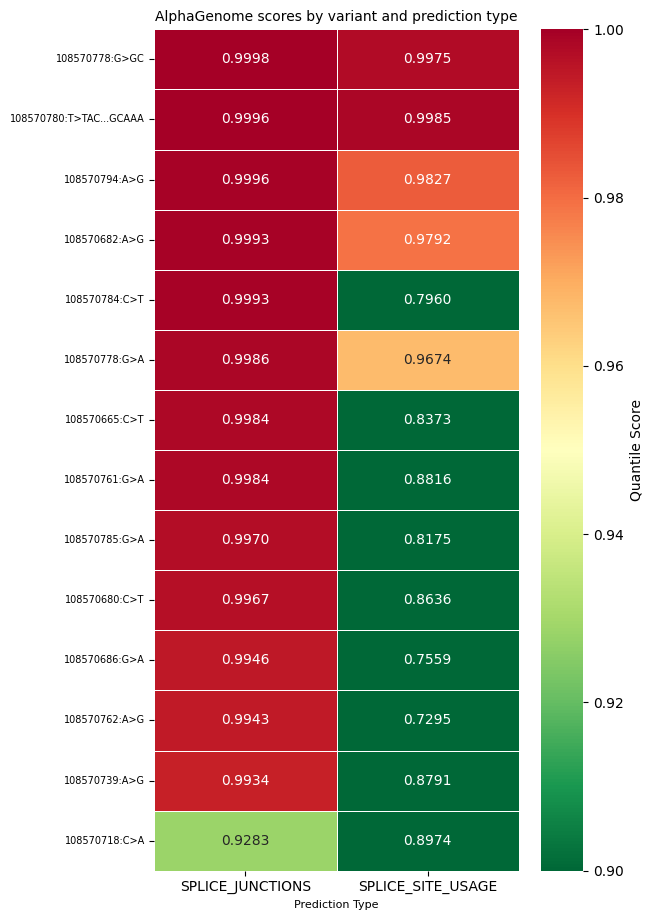

In [22]:
# Plot 1: Scores heatmap
plot_scores_heatmap(combined_df, summary_df, OUTPUT_DIR)

Saved: variant_genomic_positions.png/svg


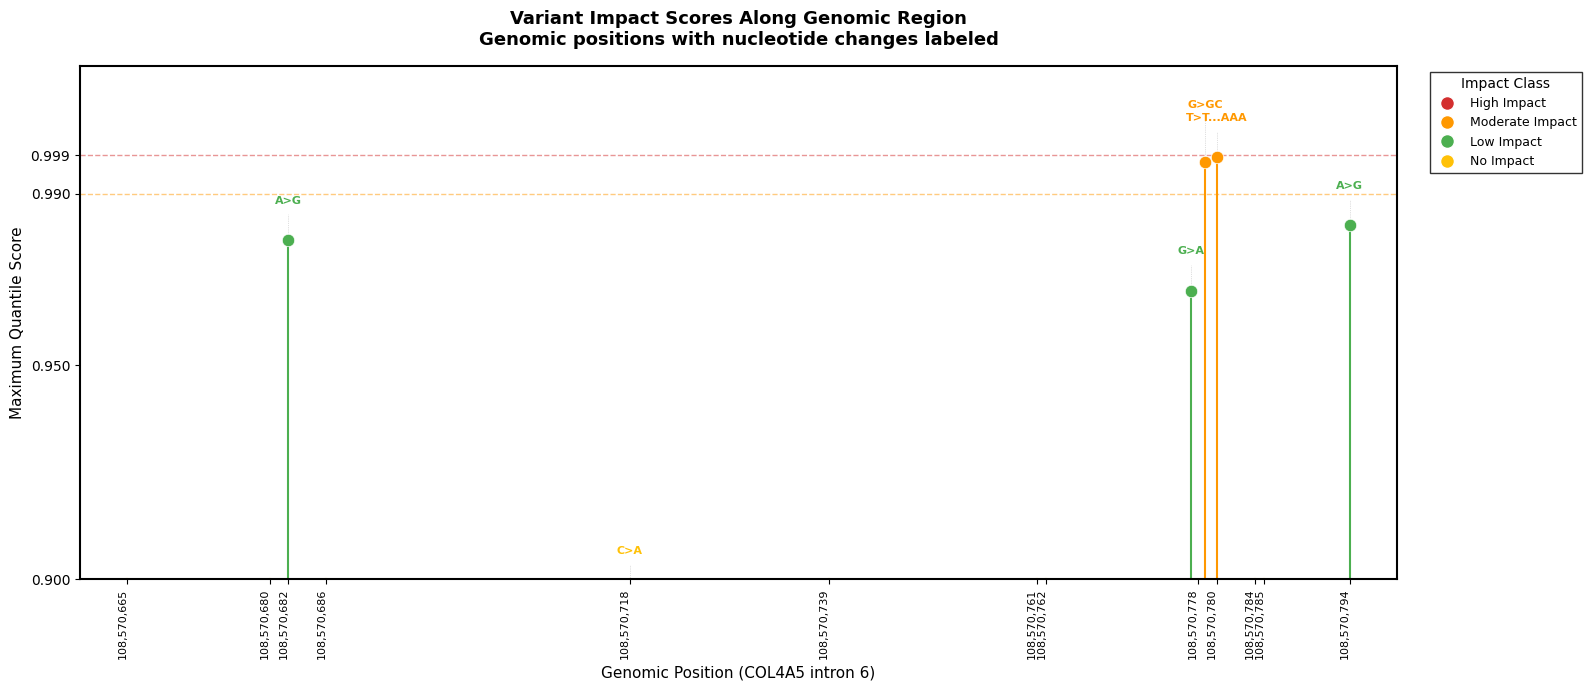

In [23]:
# Plot 2: Genomic positions
plot_genomic_positions(summary_df, OUTPUT_DIR)

### 9.4 Save Summary Table

In [26]:
# Save and display summary table
final_summary = save_summary_table(summary_df, OUTPUT_DIR)

print("\nFinal Summary Table:")
display(final_summary)

Saved: variant_pathogenicity_summary.csv

Final Summary Table:


,Variant ID,Position,Change,Impact Classification,Max Quantile Score,Max Raw Score,Mean Quantile Score,Splice Junction Max,Splice Site Max,N Predictions
0,chrX:108570778:G>GC,108570778,G>GC,Moderate Impact,0.999770,1.481445,0.998640,0.999770,0.997524,4
1,chrX:108570780:T>TACAGGTGGCATACAGGTATTTGAAAGGA...,108570780,T>TACAGGTGGCATACAGGTATTTGAAAGGAGGCAAA,Moderate Impact,0.999643,1.287109,0.998779,0.999643,0.998542,6
2,chrX:108570794:A>G,108570794,A>G,Low Impact,0.999608,1.229492,0.981391,0.999608,0.982666,8
3,chrX:108570682:A>G,108570682,A>G,Low Impact,0.999286,0.905273,0.971117,0.999286,0.979225,6
4,chrX:108570784:C>T,108570784,C>T,No Impact,0.999270,0.898926,0.941626,0.999270,0.795962,10
5,chrX:108570778:G>A,108570778,G>A,Low Impact,0.998608,0.617676,0.826256,0.998608,0.967440,6
6,chrX:108570665:C>T,108570665,C>T,No Impact,0.998401,0.564453,0.869238,0.998401,0.837278,12
7,chrX:108570761:G>A,108570761,G>A,No Impact,0.998364,0.550293,0.891342,0.998364,0.881557,10
8,chrX:108570785:G>A,108570785,G>A,No Impact,0.996955,0.355713,0.850685,0.996955,0.817526,8
9,chrX:108570680:C>T,108570680,C>T,No Impact,0.996661,0.328125,0.901481,0.996661,0.863628,14


---
## 10. Analysis Complete

All outputs have been saved to the output directory:
- `variant_pathogenicity_summary.csv` - Summary table
- `variant_impact_scores_barplot.png/svg` - Bar chart
- `variant_scores_heatmap.png/svg` - Heatmap
- `variant_genomic_positions.png/svg` - Position plot
- `variant_score_distributions.png/svg` - Distribution plots

In [27]:
# ============================================
# Separate chunk: AlphaGenome merged splicing score and ranking
# Formula (recommended):
# max(SPLICE_SITES) + max(SPLICE_SITE_USAGE) + max(SPLICE_JUNCTIONS) / 5
# ============================================

required_outputs = ['SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS']
available_outputs = set(combined_df['output_type'].unique())
missing_outputs = [o for o in required_outputs if o not in available_outputs]
if missing_outputs:
    print(f"Warning: missing output_type rows in combined_df: {missing_outputs}. Using 0 for missing components.")

# Per variant + output type max quantile
max_q = (
    combined_df.groupby(['variant_id', 'output_type'])['quantile_score']
    .max()
    .unstack(fill_value=np.nan)
    .reset_index()
)

# Ensure expected columns exist so merged score is always computable.
for col in required_outputs:
    if col not in max_q.columns:
        max_q[col] = 0.0

max_q['alphagenome_splicing_merged'] = (
    max_q['SPLICE_SITES'].fillna(0)
    + max_q['SPLICE_SITE_USAGE'].fillna(0)
    + (max_q['SPLICE_JUNCTIONS'].fillna(0) / 5.0)
)

# Merge back to summary_df (safe on re-runs)
summary_df = summary_df.drop(
    columns=['alphagenome_splicing_merged', 'alphagenome_splicing_rank'],
    errors='ignore'
)
summary_df = summary_df.merge(
    max_q[['variant_id', 'alphagenome_splicing_merged']],
    on='variant_id',
    how='left'
)

summary_df['alphagenome_splicing_rank'] = (
    summary_df['alphagenome_splicing_merged']
    .rank(method='min', ascending=False)
    .astype('Int64')
)

summary_df_splicing_ranked = (
    summary_df
    .sort_values('alphagenome_splicing_merged', ascending=False)
    .reset_index(drop=True)
)

summary_df_splicing_ranked[['short_variant', 'alphagenome_splicing_merged', 'alphagenome_splicing_rank']].head(20)

,short_variant,alphagenome_splicing_merged,alphagenome_splicing_rank
0,108570780:T>TACAGGTGGCATACAGGTATTTGAAAGGAGGCAAA,1.198471,1
1,108570778:G>GC,1.197478,2
2,108570794:A>G,1.182588,3
3,108570682:A>G,1.179082,4
4,108570778:G>A,1.167162,5
5,108570718:C>A,1.083071,6
6,108570761:G>A,1.081230,7
7,108570739:A>G,1.077797,8
8,108570680:C>T,1.062960,9
9,108570665:C>T,1.036958,10
